#  Day 1 | Classical Machine Learning
### Session 1 — From Data to Deep Learning

**Course outline coverage:**
- ✅ Introduction to AI, ML & Deep Learning
- ✅ Getting & Preparing Data (EDA, missing values, outliers, scaling)
- ✅ Supervised Learning — Classification & Regression
- ✅ Unsupervised Learning — K-Means Clustering & PCA
- ✅ Deep Learning Intro — Single Neuron & DNN in Keras

---

##  0. Install & Import Libraries

In [ ]:
# Install any missing packages (run once)
# !pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Data manipulation and visualizations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px

# Machine learning ( Classical)
# Supervised
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.inspection import DecisionBoundaryDisplay
# unsupervised
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

# Others
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PALETTE = ['#2196F3', '#4CAF50', '#FF5722']   # blue / green / orange

print("All libraries imported successfully!")
print(f"   TensorFlow: {tf.__version__}")
print(f"   Scikit-learn: {__import__('sklearn').__version__}")

All libraries imported successfully!
   TensorFlow: 2.21.0
   Scikit-learn: 1.8.0


---
##  1. Introduction: What is AI, ML, and Deep Learning?

| Term | Definition | Example |
|---|---|---|
| **AI** | Machines mimicking human intelligence | Self-driving cars, Chatbots |
| **ML** | Algorithms that *learn* from data | Spam filter, M-Pesa fraud detection |
| **Deep Learning** | ML using neural networks with many layers | Image recognition, ChatGPT |



---
##  2. Getting & Preparing Data — Iris Dataset

We load the Iris dataset directly from a URL so **everyone can run this notebook** without local files.
<img src = "https://media.licdn.com/dms/image/v2/D4D12AQHXgEDzTf_p-w/article-inline_image-shrink_1500_2232/article-inline_image-shrink_1500_2232/0/1720968777920?e=1777507200&v=beta&t=-WatREouuoWXvkV75dQ-rRn-sDNrDkDytTBpRrXwfMQ">

In [53]:
# ── Load Iris via URL (works on any machine) ──────────────────────────────────
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
iris = pd.read_csv(URL)

print("Iris dataset loaded from URL")
print(f"   Shape: {iris.shape}  ({iris.shape[0]} rows × {iris.shape[1]} columns)")
print(f"   Classes: {iris['species'].unique()}")
iris.head()

Iris dataset loaded from URL
   Shape: (150, 5)  (150 rows × 5 columns)
   Classes: <StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [38]:
# ── 2a. Basic EDA ─────────────────────────────────────────────────────────────
print("=" * 50)
print("DESCRIPTIVE STATISTICS  —  df.describe()")
print("=" * 50)
iris.describe().round(2)

DESCRIPTIVE STATISTICS  —  df.describe()


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [54]:
# ── 2b. Missing values ────────────────────────────────────────────────────────
print("Missing values per column:")
print(iris.isnull().sum())
print(f"\nClass balance:")
print(iris['species'].value_counts())

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class balance:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


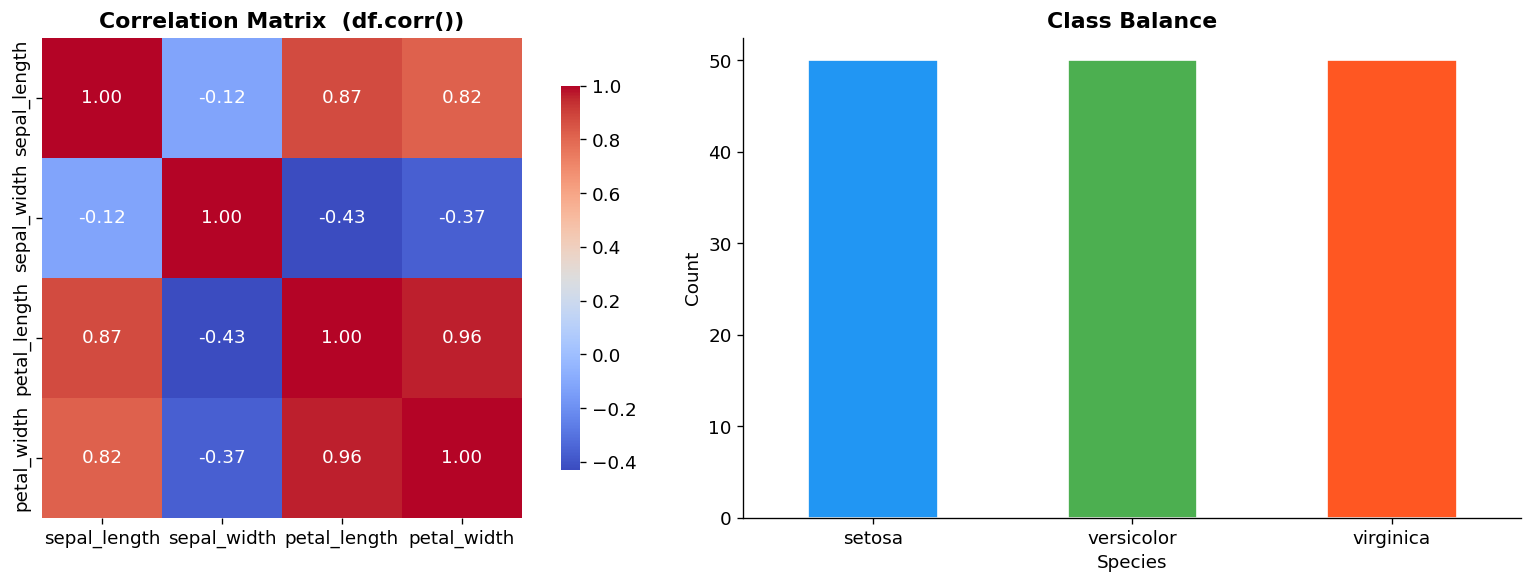

In [55]:
# ── 2c. Correlation matrix — df.corr() ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pairplot (distribution + scatter)
numeric_cols = iris.select_dtypes(include=np.number).columns.tolist()
corr = iris[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Matrix  (df.corr())', fontweight='bold')

# Class distribution
iris['species'].value_counts().plot(kind='bar', color=PALETTE, ax=axes[1], edgecolor='white')
axes[1].set_title('Class Balance', fontweight='bold')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

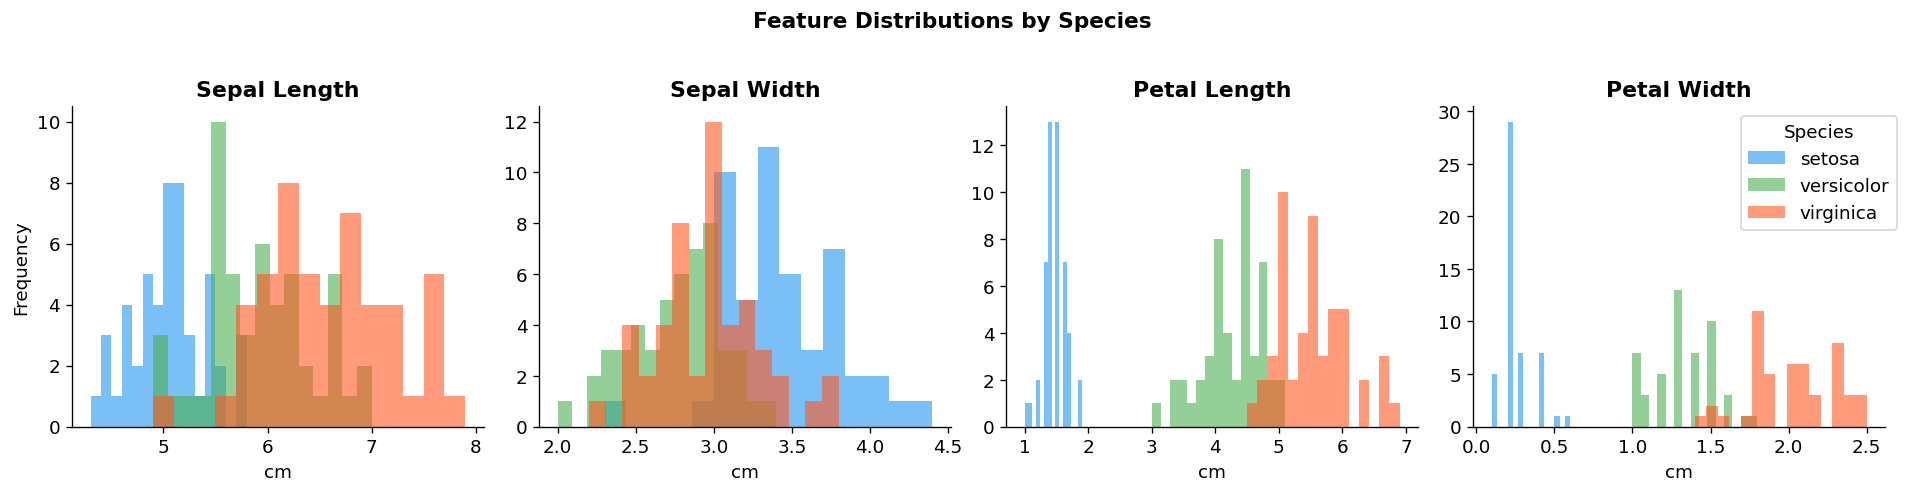

In [56]:
# ── 2d. Feature distributions ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    for i, (sp, grp) in enumerate(iris.groupby('species')):
        ax.hist(grp[col], alpha=0.6, color=PALETTE[i], label=sp, bins=15)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('cm')
axes[0].set_ylabel('Frequency')
axes[-1].legend(title='Species', bbox_to_anchor=(1.05, 1))
fig.suptitle('Feature Distributions by Species', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Outlier Detection

We use **boxplots** (visual) and the **IQR method** (statistical) to flag outliers.

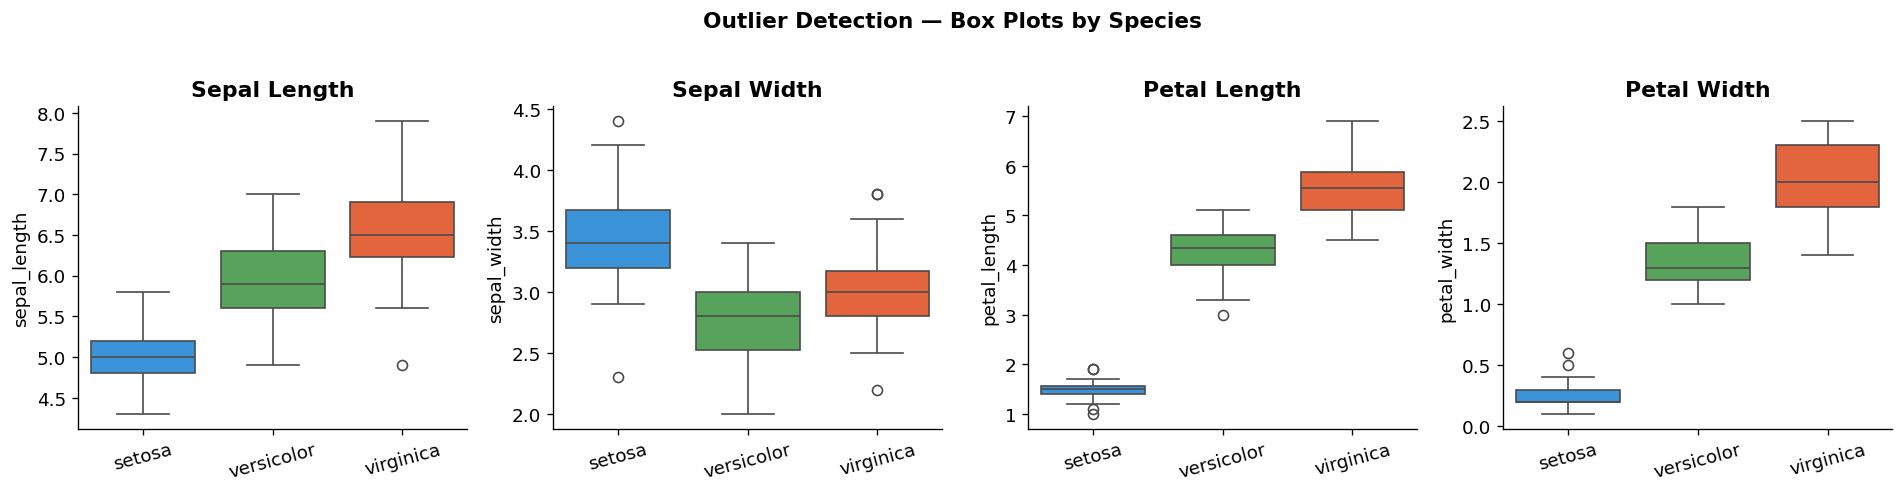

In [57]:
# ── 3a. Boxplot visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=iris, x='species', y=col, palette=PALETTE, ax=ax)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
fig.suptitle('Outlier Detection — Box Plots by Species', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [58]:
# ── 3b. IQR method ───────────────────────────────────────────────────────────
print("IQR Outlier Detection")
print("=" * 45)
total_outliers = 0
for col in numeric_cols:
    Q1 = iris[col].quantile(0.25)
    Q3 = iris[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((iris[col] < lo) | (iris[col] > hi)).sum()
    total_outliers += n_out
    print(f"{col:25s}  IQR={IQR:.2f}  bounds=[{lo:.2f}, {hi:.2f}]  outliers={n_out}")

print(f"\nTotal outlier rows detected: {total_outliers}")
print("Iris is a clean dataset — outlier count is very low.")

IQR Outlier Detection
sepal_length               IQR=1.30  bounds=[3.15, 8.35]  outliers=0
sepal_width                IQR=0.50  bounds=[2.05, 4.05]  outliers=4
petal_length               IQR=3.50  bounds=[-3.65, 10.35]  outliers=0
petal_width                IQR=1.50  bounds=[-1.95, 4.05]  outliers=0

Total outlier rows detected: 4
Iris is a clean dataset — outlier count is very low.


---
## 4. Feature Scaling

Most ML algorithms are sensitive to feature scale. We compare **StandardScaler** and **MinMaxScaler**.

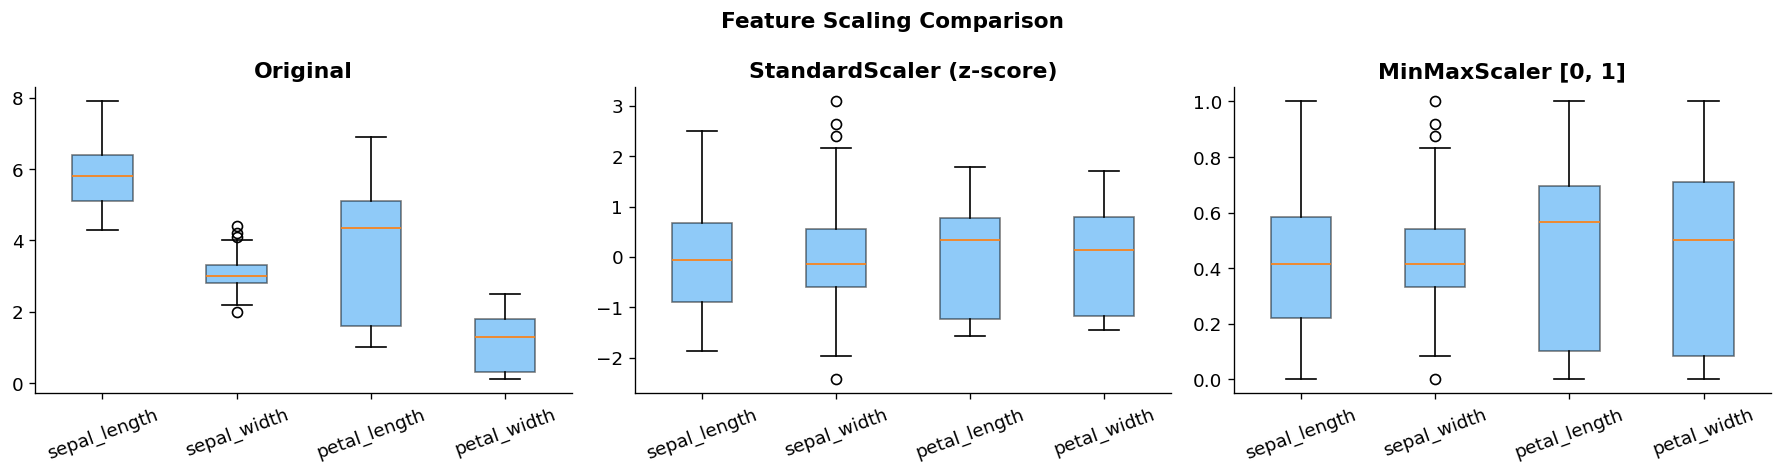

We will use StandardScaler for ML models.


In [59]:
X = iris[numeric_cols].values
y_raw = iris['species'].values

# Encode labels: setosa=0, versicolor=1, virginica=2
le = LabelEncoder()
y = le.fit_transform(y_raw)

X_std   = StandardScaler().fit_transform(X)
X_minmax = MinMaxScaler().fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
titles = ['Original', 'StandardScaler (z-score)', 'MinMaxScaler [0, 1]']
for ax, data, title in zip(axes, [X, X_std, X_minmax], titles):
    ax.boxplot(data, labels=numeric_cols, patch_artist=True,
               boxprops=dict(facecolor='#2196F3', alpha=0.5))
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
fig.suptitle('Feature Scaling Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("We will use StandardScaler for ML models.")

---
## 5. Supervised Learning — Classification

We train three classifiers on the Iris dataset:
1. **Logistic Regression** — linear, probabilistic
2. **Random Forest** — ensemble of decision trees
3. **Gradient Boosting** — sequential boosting ensemble

Then we plot **decision boundaries** for all three.

In [ ]:
print(iris.head())
print(iris.columns)
# step 1 -  ( define the X and the Y)
Y =  iris['species']
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
print(Y[:5])
print(X.iloc[1:5,:])

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: str
   sepal_length  sepal_width  petal_length  petal_width
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


<img src = "../images/train_test_split.png">

In [60]:
# step 2 -  ( Train test split)
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(120, 4) (30, 4) (120,) (30,)


In [61]:
# Step 3 - train the model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
# Step 4 - test or evaluate the model
from sklearn.metrics import confusion_matrix,accuracy_score
pred = model.predict(x_test)
print(pred[:6])
print(y_test[:6])
print(confusion_matrix(pred,y_test))
print(accuracy_score(pred,y_test))

['versicolor' 'versicolor' 'virginica' 'virginica' 'setosa' 'setosa']
53     versicolor
63     versicolor
134     virginica
113     virginica
30         setosa
10         setosa
Name: species, dtype: str
[[ 9  0  0]
 [ 0  7  0]
 [ 0  2 12]]
0.9333333333333333


In [62]:
# ── 5a. Train / Test Split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")

# ── 5b. Define classifiers ─────────────────────────────────────────────────────
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv  = cross_val_score(clf, X_std, y, cv=5).mean()
    results[name] = {'model': clf, 'y_pred': y_pred, 'accuracy': acc, 'cv_accuracy': cv}
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"  Test Accuracy: {acc:.3f}  |  5-fold CV: {cv:.3f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

Train: 120 samples  |  Test: 30 samples

───────────────────────────────────────────────────────
  Logistic Regression
  Test Accuracy: 0.933  |  5-fold CV: 0.960
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


───────────────────────────────────────────────────────
  Random Forest
  Test Accuracy: 0.933  |  5-fold CV: 0.967
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg 

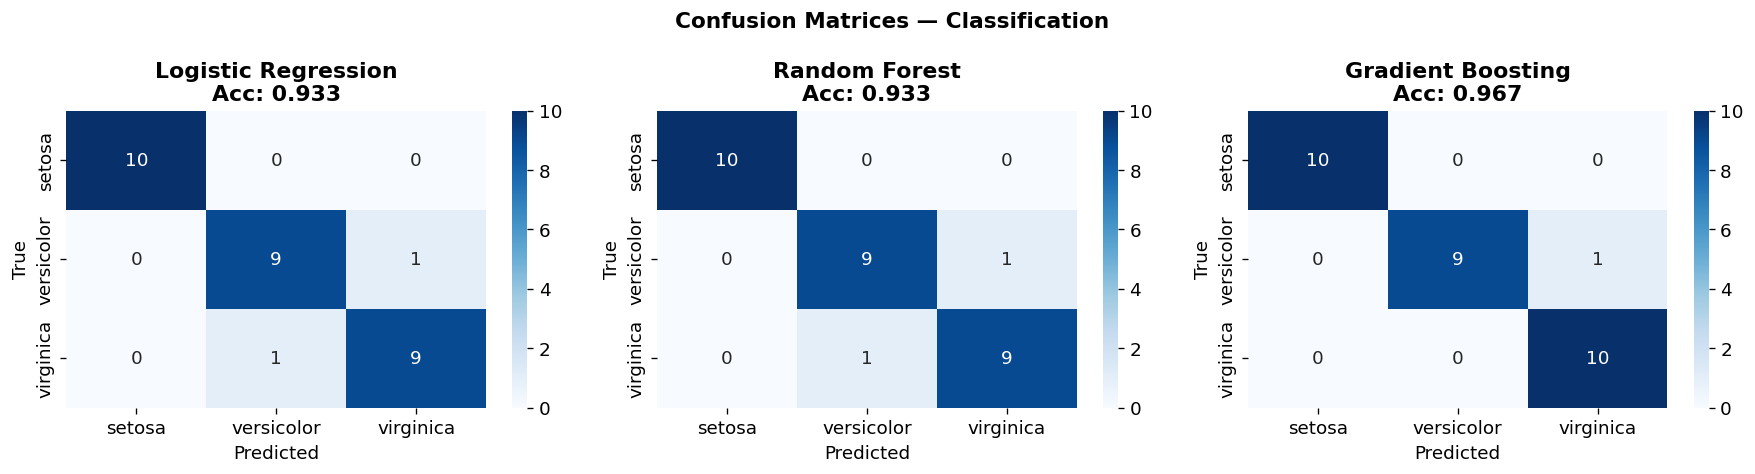

In [63]:
# ── 5c. Confusion matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f"{name}\nAcc: {res['accuracy']:.3f}", fontweight='bold')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices — Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

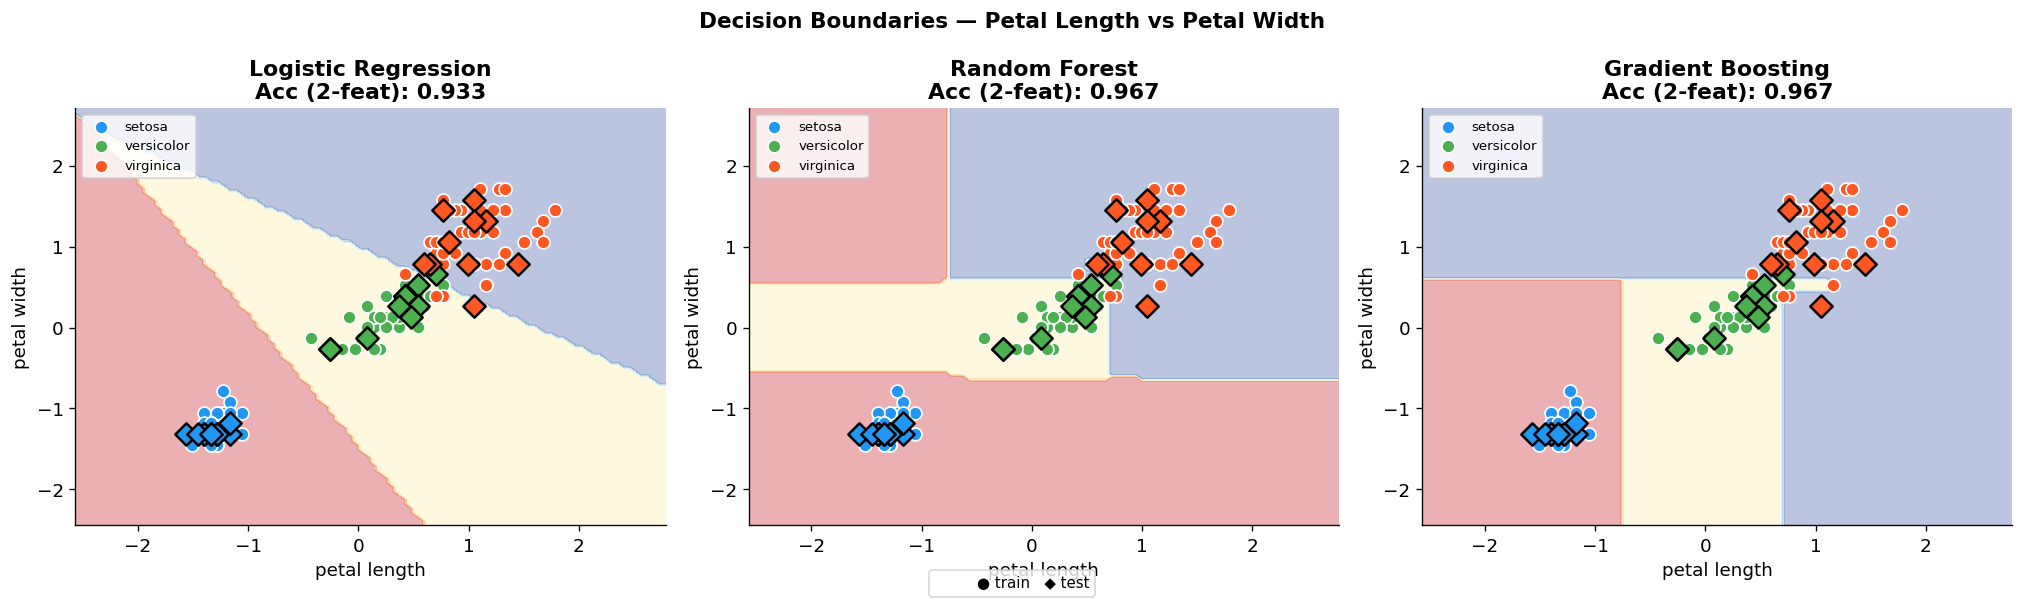

In [64]:
# ── 5d. Decision Boundary Plots (2 features for visualisation) ────────────────
# Use only petal_length & petal_width (best separators)
feat_idx = [2, 3]   # petal_length, petal_width
feat_names = [numeric_cols[i] for i in feat_idx]

X2 = X_std[:, feat_idx]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

# Retrain on 2 features for boundary visualisation
clfs_2d = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
cmap_bg   = plt.cm.RdYlBu

for ax, (name, clf2) in zip(axes, clfs_2d.items()):
    clf2.fit(X2_train, y2_train)
    acc2 = accuracy_score(y2_test, clf2.predict(X2_test))

    # Decision boundary
    DecisionBoundaryDisplay.from_estimator(
        clf2, X2, response_method='predict',
        cmap=cmap_bg, alpha=0.35, ax=ax
    )
    # Scatter training points
    for cls_idx, (sp, c) in enumerate(zip(le.classes_, PALETTE)):
        mask = y2_train == cls_idx
        ax.scatter(X2_train[mask, 0], X2_train[mask, 1],
                   color=c, edgecolors='white', s=60, label=sp)
    # Scatter test points with bold border
    for cls_idx, c in enumerate(PALETTE):
        mask = y2_test == cls_idx
        ax.scatter(X2_test[mask, 0], X2_test[mask, 1],
                   color=c, edgecolors='black', s=90, linewidths=1.5, marker='D')

    ax.set_title(f"{name}\nAcc (2-feat): {acc2:.3f}", fontweight='bold')
    ax.set_xlabel(feat_names[0].replace('_', ' '))
    ax.set_ylabel(feat_names[1].replace('_', ' '))
    ax.legend(fontsize=8, loc='upper left')

# Legend note
circle = mpatches.Patch(facecolor='none', label='● train   ◆ test')
fig.legend(handles=[circle], loc='lower center', ncol=1, fontsize=9)
fig.suptitle('Decision Boundaries — Petal Length vs Petal Width', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  6. Supervised Learning — Regression

We switch to a different dataset — **California Housing** — to demonstrate regression.

**Goal:** Predict median house value from housing features.

Common metrics:
- **RMSE** — Root Mean Squared Error (in target units)
- **MAE** — Mean Absolute Error (robust to outliers)
- **R²** — Proportion of variance explained (1.0 = perfect)

In [65]:
# ── 6a. Load California Housing ───────────────────────────────────────────────


df_house = pd.read_csv("https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv")
print("California Housing dataset loaded")
print(f"   Shape: {df_house.shape}")
print(f"   Target: MedHouseVal (median house value in $100,000s)")
print(df_house.head())
df_house.columns


California Housing dataset loaded
   Shape: (20640, 10)
   Target: MedHouseVal (median house value in $100,000s)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462 

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [66]:
# X and Y split
X = df_house[["total_rooms","median_income"]]
Y = df_house["median_house_value"]
# train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)
# train the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
# evaluate the model
pred = model.predict(x_test)
print(pred[:5])
print(y_test[:5])

(16512, 2) (4128, 2) (16512,) (4128,)
[163995.78882411 152154.49082659 221722.95463337 127427.13903726
 165946.80940252]
14444    227800.0
9586     121600.0
10755    500001.0
6438     226000.0
15915    246400.0
Name: median_house_value, dtype: float64


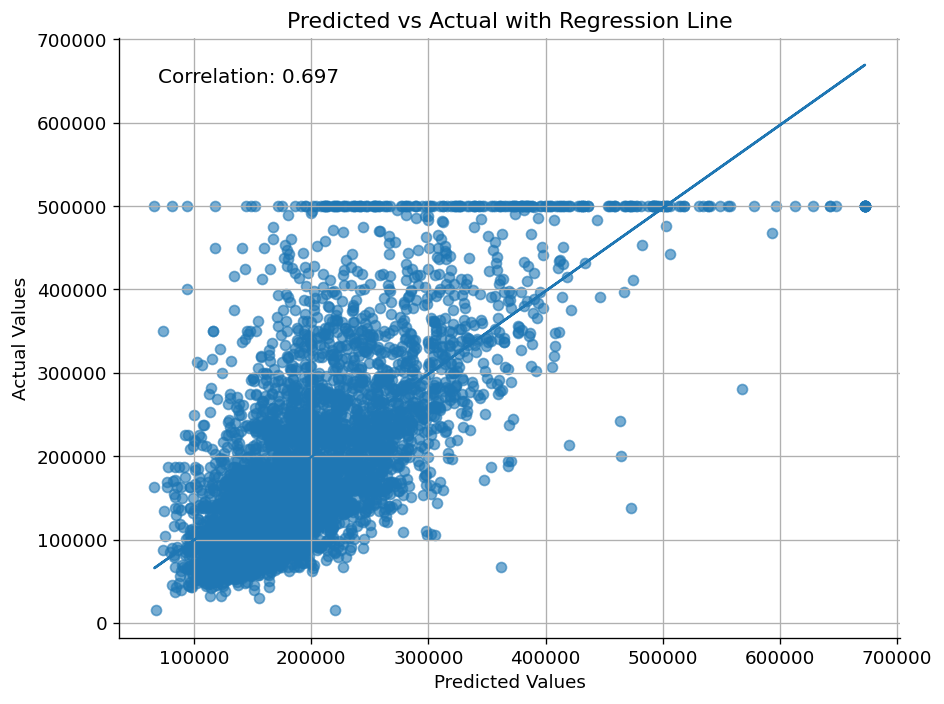

In [67]:
# Compute correlation
corr = np.corrcoef(pred, y_test)[0, 1]

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(pred, y_test, alpha=0.6)

# Fit regression line
m, b = np.polyfit(pred, y_test, 1)
plt.plot(pred, m * pred + b)

# Labels and title
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Predicted vs Actual with Regression Line")

# Annotate correlation
plt.text(
    0.05, 0.95,
    f"Correlation: {corr:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

# Improve layout
plt.grid(True)
plt.tight_layout()

plt.show()

In [68]:
# ── 6b. Train regression models ───────────────────────────────────────────────

# Encode categorical column
df_house_encoded = df_house.copy()
df_house_encoded['ocean_proximity'] = LabelEncoder().fit_transform(df_house['ocean_proximity'])

# Drop rows with missing values (total_bedrooms has NaNs in this dataset)
df_house_encoded = df_house_encoded.dropna()

X_h = df_house_encoded.drop('median_house_value', axis=1).values
y_h = df_house_encoded['median_house_value'].values

X_h_scaled = StandardScaler().fit_transform(X_h)
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(
    X_h_scaled, y_h, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

reg_models = {
    'Linear Regression':          LinearRegression(),
    'Random Forest Regressor':    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

print(f"{'Model':<30} {'RMSE':>10} {'MAE':>10} {'R²':>8}")
print("─" * 62)

reg_results = {}
for name, reg in reg_models.items():
    reg.fit(Xh_tr, yh_tr)
    yh_pred = reg.predict(Xh_te)
    rmse = np.sqrt(mean_squared_error(yh_te, yh_pred))
    mae  = mean_absolute_error(yh_te, yh_pred)
    r2   = r2_score(yh_te, yh_pred)
    reg_results[name] = {'model': reg, 'pred': yh_pred, 'rmse': rmse, 'mae': mae, 'r2': r2}
    print(f"{name:<30} {rmse:>10,.0f} {mae:>10,.0f} {r2:>8.3f}")

print("\n💡 Note: RMSE/MAE are in dollars (house values range ~$15k–$500k)")

Model                                RMSE        MAE       R²
──────────────────────────────────────────────────────────────
Linear Regression                  70,172     51,389    0.640
Random Forest Regressor            49,503     32,158    0.821
Gradient Boosting Regressor        56,513     39,395    0.766

💡 Note: RMSE/MAE are in dollars (house values range ~$15k–$500k)


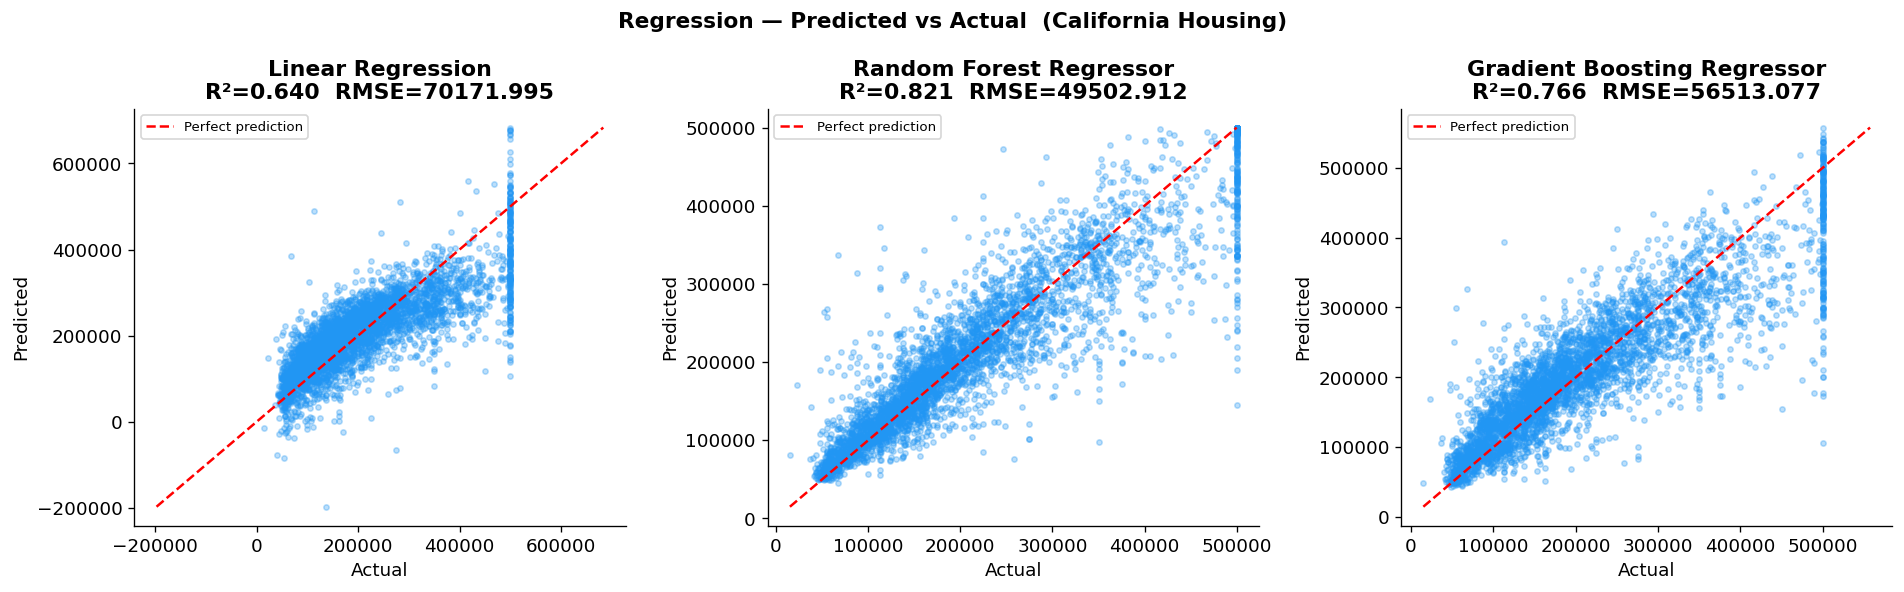


💡 R² closer to 1.0 and lower RMSE/MAE = better model.


In [69]:
# ── 6c. Predicted vs Actual plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, res) in zip(axes, reg_results.items()):
    ax.scatter(yh_te, res['pred'], alpha=0.3, s=10, color='#2196F3')
    lims = [min(yh_te.min(), res['pred'].min()), max(yh_te.max(), res['pred'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_title(f"{name}\nR²={res['r2']:.3f}  RMSE={res['rmse']:.3f}", fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend(fontsize=8)
fig.suptitle('Regression — Predicted vs Actual  (California Housing)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n💡 R² closer to 1.0 and lower RMSE/MAE = better model.")

---
## 🔵 7. Unsupervised Learning — K-Means Clustering + PCA

Back to Iris — but this time **without** labels.

- **K-Means**: groups similar flowers into *k* clusters
- **PCA**: compresses 4 features → 2 dimensions for visualisation

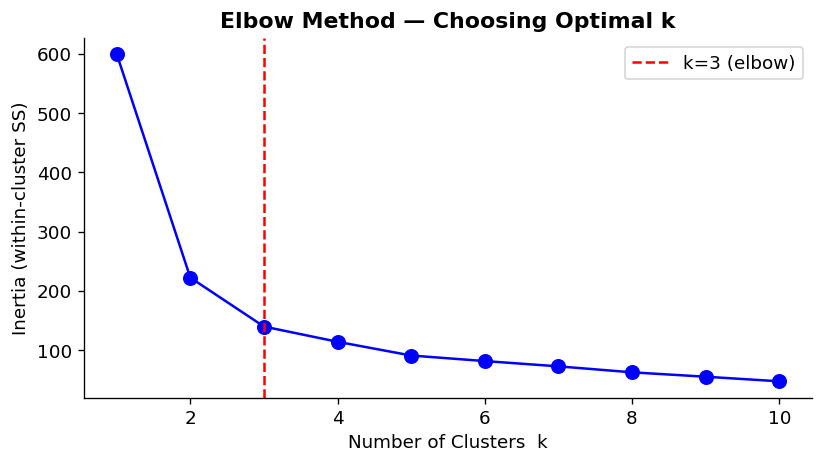

In [23]:
# ── 7a. Elbow method — choosing k ─────────────────────────────────────────────
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_std)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'bo-', markersize=8)
plt.axvline(3, color='red', linestyle='--', label='k=3 (elbow)')
plt.xlabel('Number of Clusters  k')
plt.ylabel('Inertia (within-cluster SS)')
plt.title('Elbow Method — Choosing Optimal k', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
# ── 7b. K-Means with k=3 ─────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_std)

# ── 7c. PCA — reduce to 2 components ──────────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance explained by PC1+PC2: {pca.explained_variance_ratio_.sum():.1%}")

PCA explained variance ratio: [0.73  0.229]
Total variance explained by PC1+PC2: 95.8%


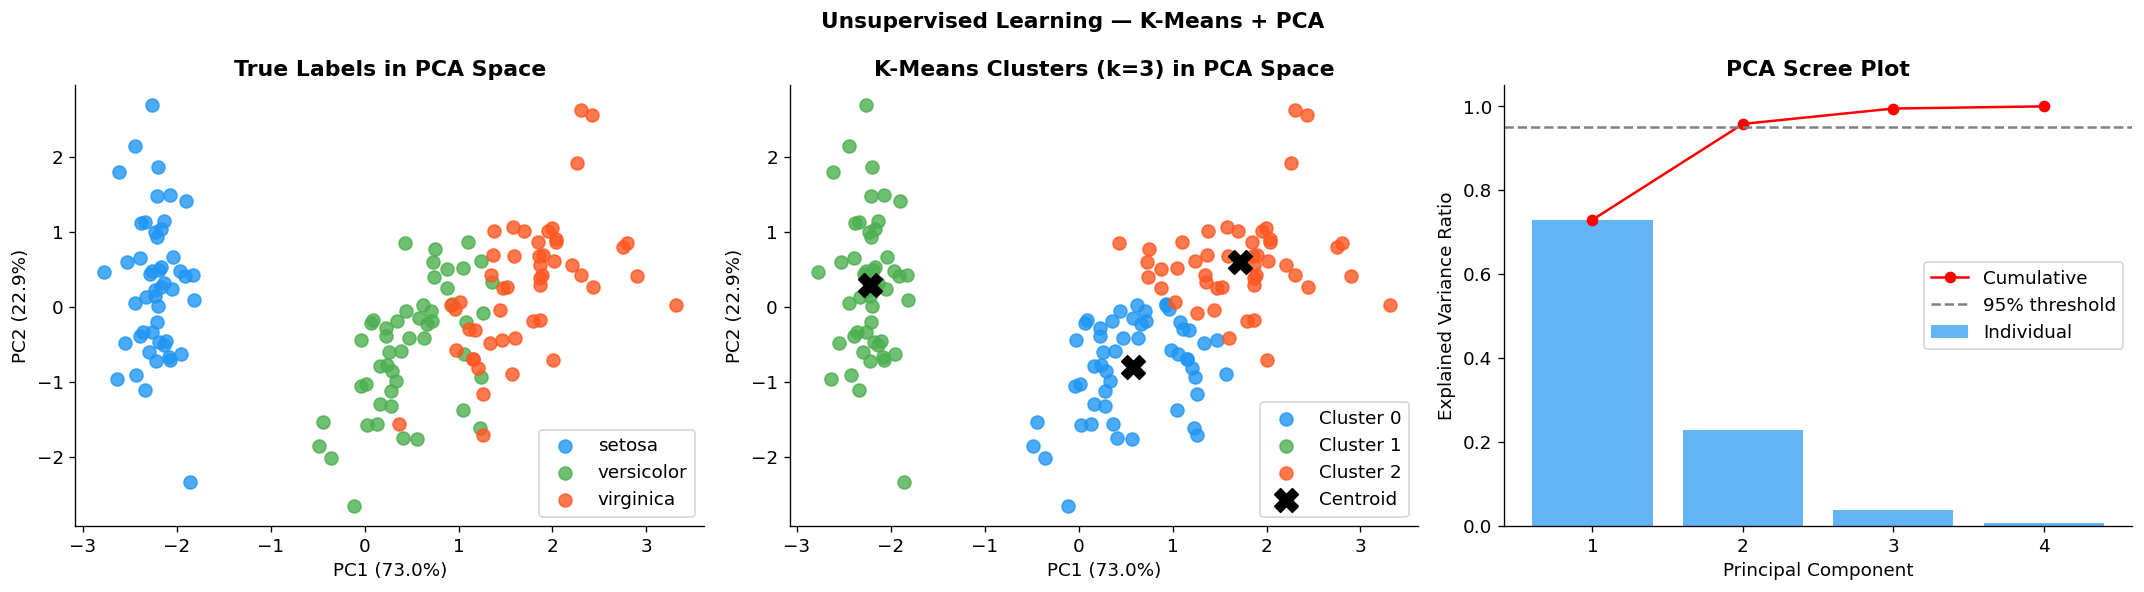

In [77]:
# ── 7d. Visualise Clusters & PCA ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — True species labels in PCA space
for i, sp in enumerate(le.classes_):
    mask = y == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=PALETTE[i], label=sp, s=60, alpha=0.8)
axes[0].set_title('True Labels in PCA Space', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend()

# Plot 2 — K-Means clusters in PCA space
for c in range(3):
    mask = cluster_labels == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=PALETTE[c], label=f'Cluster {c}', s=60, alpha=0.8)
# Centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[1].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='X', s=200, color='black', zorder=5, label='Centroid')
axes[1].set_title('K-Means Clusters (k=3) in PCA Space', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].legend()

# Plot 3 — PCA scree plot
pca_full = PCA()
pca_full.fit(X_std)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[2].bar(range(1, 5), pca_full.explained_variance_ratio_, color=PALETTE[0], alpha=0.7, label='Individual')
axes[2].plot(range(1, 5), cumvar, 'ro-', label='Cumulative')
axes[2].axhline(0.95, linestyle='--', color='grey', label='95% threshold')
axes[2].set_xlabel('Principal Component')
axes[2].set_ylabel('Explained Variance Ratio')
axes[2].set_title('PCA Scree Plot', fontweight='bold')
axes[2].legend()
axes[2].set_xticks(range(1, 5))

fig.suptitle('Unsupervised Learning — K-Means + PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Deep Learning — Single Neuron (Perceptron) in Keras

A **single neuron** is the simplest neural network:
- Takes 4 inputs (sepal/petal length & width)
- Applies weights + bias + activation
- Outputs class probabilities

This is mathematically equivalent to **Logistic Regression** with one layer.

<img src = "https://miro.medium.com/1*O7YSSqlOdQuNgMrH7J_3dg.png">

In [78]:
# ── 8a. Prepare data for Keras ────────────────────────────────────────────────
# One-hot encode labels for multi-class softmax
y_ohe = to_categorical(y, num_classes=3)

X_tr_k, X_te_k, y_tr_k, y_te_k = train_test_split(
    X_std, y_ohe, test_size=0.2, random_state=42
)

print(f"Train: {X_tr_k.shape[0]}  |  Test: {X_te_k.shape[0]}")
print(f"Label shape (one-hot): {y_tr_k.shape}")
y_ohe

Train: 120  |  Test: 30
Label shape (one-hot): (120, 3)


array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

In [79]:
# ── 8b. Single Neuron model ───────────────────────────────────────────────────
tf.random.set_seed(42)

single_neuron = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(3, activation='softmax', name='single_neuron')   # 1 dense layer = 1 neuron per class
], name='SingleNeuron')

single_neuron.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

single_neuron.summary()

Model: "SingleNeuron"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ single_neuron (Dense)           │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [80]:
# ── 8c. Train Single Neuron ───────────────────────────────────────────────────
history_sn = single_neuron.fit(
    X_tr_k, y_tr_k,
    epochs=100,
    batch_size=16,
    validation_split=0.15,
    verbose=0
)

loss_sn, acc_sn = single_neuron.evaluate(X_te_k, y_te_k, verbose=0)
print(f"\nSingle Neuron — Test Accuracy: {acc_sn:.3f}  |  Loss: {loss_sn:.3f}")


Single Neuron — Test Accuracy: 0.933  |  Loss: 0.548


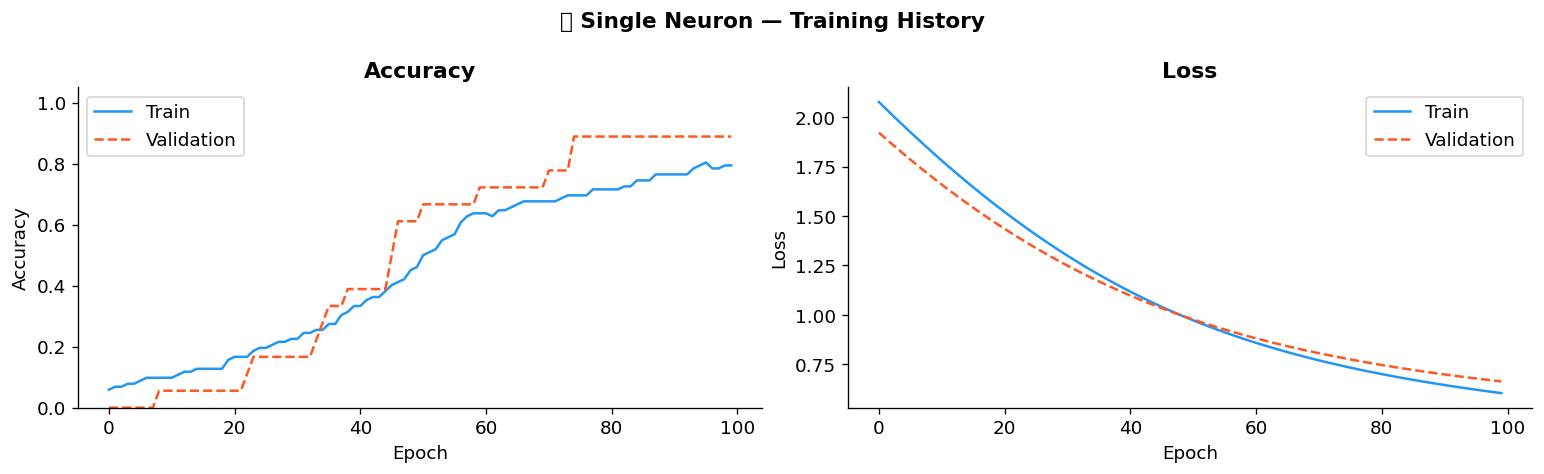

In [81]:
# ── 8d. Plot Training History — Single Neuron ─────────────────────────────────
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    # Accuracy
    axes[0].plot(history.history['accuracy'],     color='#2196F3', label='Train')
    axes[0].plot(history.history['val_accuracy'], color='#FF5722', linestyle='--', label='Validation')
    axes[0].set_title('Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].set_ylim([0, 1.05])
    # Loss
    axes[1].plot(history.history['loss'],     color='#2196F3', label='Train')
    axes[1].plot(history.history['val_loss'], color='#FF5722', linestyle='--', label='Validation')
    axes[1].set_title('Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history_sn, '🔵 Single Neuron — Training History')

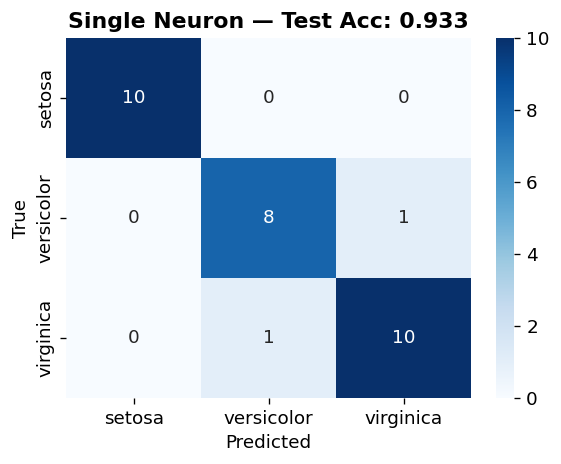

In [82]:
# ── 8e. Confusion matrix — Single Neuron ─────────────────────────────────────
y_pred_sn = np.argmax(single_neuron.predict(X_te_k, verbose=0), axis=1)
y_true_k  = np.argmax(y_te_k, axis=1)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_true_k, y_pred_sn), annot=True, fmt='d',
            cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Single Neuron — Test Acc: {acc_sn:.3f}', fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## 9. Deep Learning — DNN with 1 Hidden Layer in Keras

A **Deep Neural Network (DNN)** adds hidden layers between input and output:

```
Input (4)  →  Hidden Layer (64, ReLU)  →  Dropout  →  Output (3, Softmax)
```

The hidden layer learns non-linear feature representations — a key advantage over Logistic Regression.

<img src = "https://miro.medium.com/v2/resize:fit:1400/1*bz59rluxfbLe55oQ3bIeEw.png" >

In [83]:
# ── 9a. Build DNN ─────────────────────────────────────────────────────────────
tf.random.set_seed(42)

dnn = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(64, activation='relu', name='hidden_layer_1'),
    layers.Dropout(0.2, name='dropout'),                         # regularisation
    layers.Dense(3, activation='softmax', name='output_layer')
], name='DNN_1HiddenLayer')

dnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dnn.summary()

Model: "DNN_1HiddenLayer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515 (2.01 KB)

 Trainable params: 515 (2.01 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
# ── 9b. Train DNN ─────────────────────────────────────────────────────────────
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_dnn = dnn.fit(
    X_tr_k, y_tr_k,
    epochs=200,
    batch_size=16,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=0
)

loss_dnn, acc_dnn = dnn.evaluate(X_te_k, y_te_k, verbose=0)
print(f"\nDNN — Test Accuracy: {acc_dnn:.3f}  |  Loss: {loss_dnn:.3f}")
print(f"Stopped at epoch: {len(history_dnn.history['loss'])}")


DNN — Test Accuracy: 1.000  |  Loss: 0.060
Stopped at epoch: 6


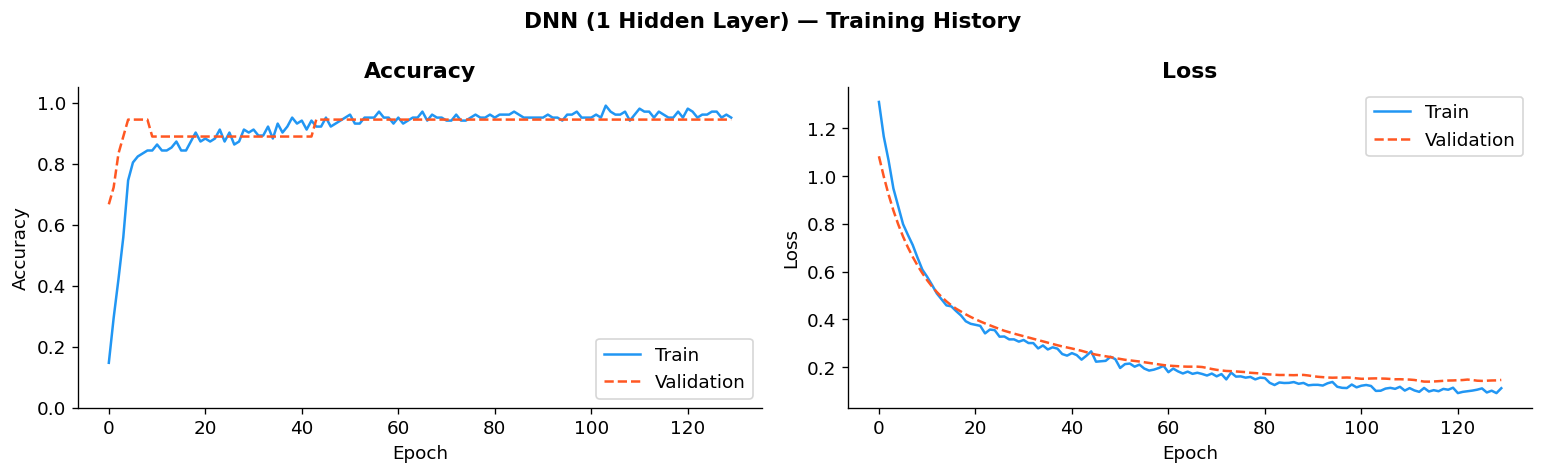

In [34]:
# ── 9c. Plot Training History — DNN ──────────────────────────────────────────
plot_history(history_dnn, 'DNN (1 Hidden Layer) — Training History')

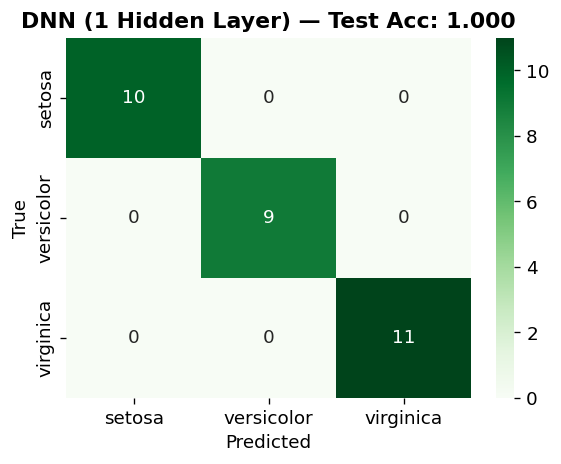

In [86]:
# ── 9d. Confusion matrix — DNN ────────────────────────────────────────────────
y_pred_dnn = np.argmax(dnn.predict(X_te_k, verbose=0), axis=1)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_true_k, y_pred_dnn), annot=True, fmt='d',
            cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'DNN (1 Hidden Layer) — Test Acc: {acc_dnn:.3f}', fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## 10. Final Summary — Model Comparison

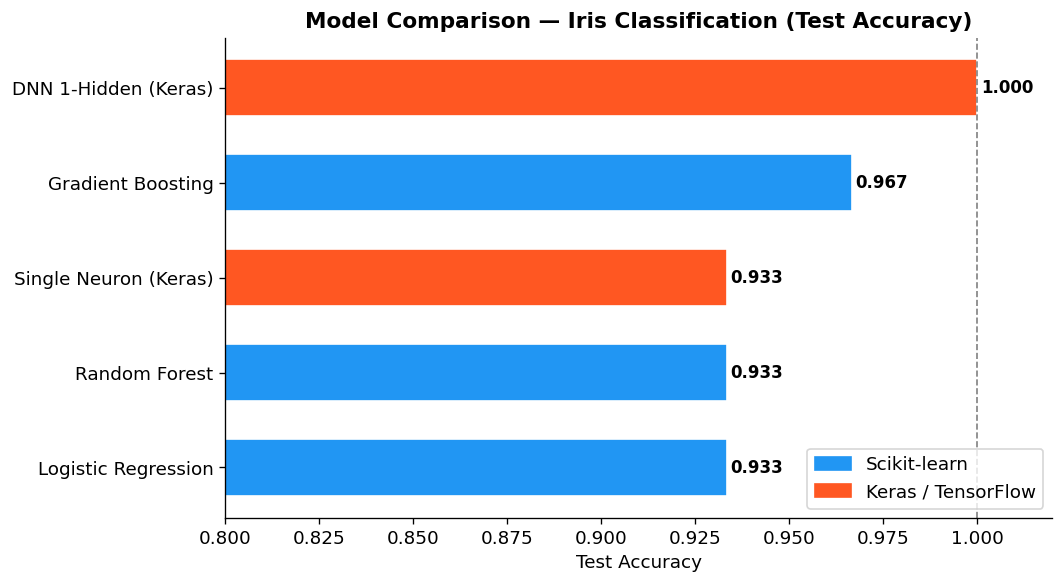


📌 Key Takeaways:
  • Iris is a clean, small dataset — most models hit ~96–100% accuracy
  • Deep learning shines on larger, more complex data (images, text, sequences)
  • Classical ML is faster to train and often preferable for tabular data
  • Always evaluate with held-out test data + cross-validation


In [87]:
# ── Full model comparison on Iris classification ──────────────────────────────
summary = {
    'Logistic Regression':  results['Logistic Regression']['accuracy'],
    'Random Forest':        results['Random Forest']['accuracy'],
    'Gradient Boosting':    results['Gradient Boosting']['accuracy'],
    'Single Neuron (Keras)': acc_sn,
    'DNN 1-Hidden (Keras)': acc_dnn,
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Test Accuracy'])
summary_df = summary_df.sort_values('Test Accuracy', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#FF5722' if 'Keras' in m else '#2196F3' for m in summary_df.index]
bars = ax.barh(summary_df.index, summary_df['Test Accuracy'], color=colors_bar, edgecolor='white', height=0.6)
ax.set_xlim(0.8, 1.02)
ax.axvline(1.0, color='grey', linestyle='--', linewidth=1)
for bar, val in zip(bars, summary_df['Test Accuracy']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
blue_patch  = mpatches.Patch(color='#2196F3', label='Scikit-learn')
red_patch   = mpatches.Patch(color='#FF5722', label='Keras / TensorFlow')
ax.legend(handles=[blue_patch, red_patch], loc='lower right')
ax.set_title('Model Comparison — Iris Classification (Test Accuracy)', fontsize=13, fontweight='bold')
ax.set_xlabel('Test Accuracy')
plt.tight_layout()
plt.show()

print("\n📌 Key Takeaways:")
print("  • Iris is a clean, small dataset — most models hit ~96–100% accuracy")
print("  • Deep learning shines on larger, more complex data (images, text, sequences)")
print("  • Classical ML is faster to train and often preferable for tabular data")
print("  • Always evaluate with held-out test data + cross-validation")

---
## ❓ Q&A — Classical ML: When it Works, When it Doesn't

| Situation | Recommendation |
|---|---|
| Small tabular dataset | ✅ Classical ML (RF, Logistic) |
| Large image / audio / text | ✅ Deep Learning (CNN / RNN / Transformer) |
| Need explainability | ✅ Decision Trees, Logistic Regression |
| Fast training required | ✅ Linear models, Gradient Boosting |
| Complex non-linear patterns | ✅ DNN, Gradient Boosting |
| Very limited data | ⚠️ Classical ML or transfer learning |

---
*End of Session 1 — Classical Machine Learning*  
*Next: CNNs (images) · RNNs/LSTMs (sequences) · Transformers (text)*